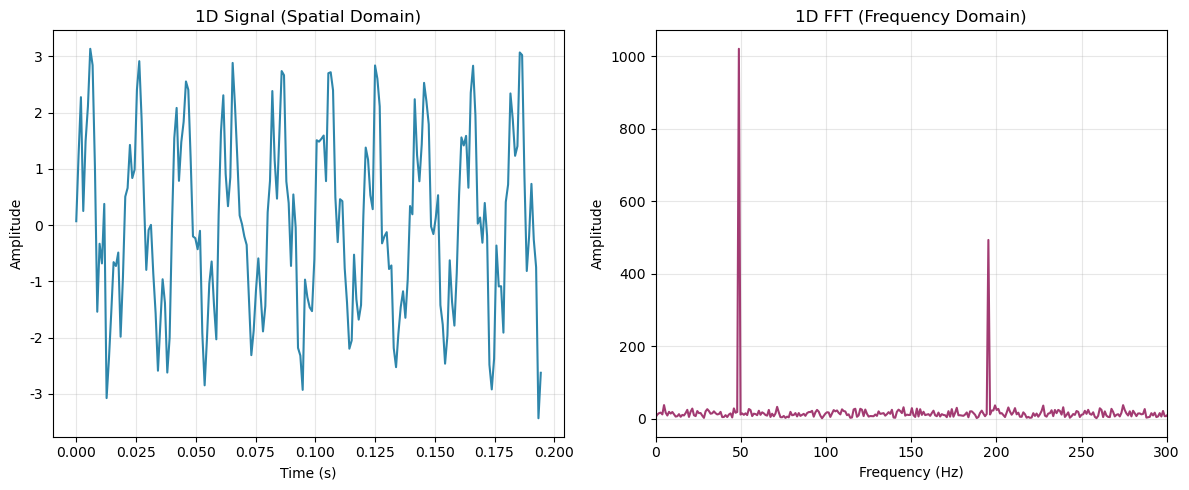

逆变换与原信号均方误差：0.00000000


In [3]:
# 导入库
import numpy as np
import matplotlib.pyplot as plt

# 设置字体（避免乱码）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ===================== 一维傅里叶变换核心代码 =====================
# 1. 生成一维混合信号（低频+高频+噪声）
N = 1024  # 采样点数量
Fs = 1000  # 采样频率（Hz）
t = np.linspace(0, 1, N, endpoint=False)  # 时间轴：0~1秒

# 构造信号：50Hz低频 + 200Hz高频 + 少量噪声
signal_low = 2 * np.sin(2 * np.pi * 50 * t)   # 低频分量（振幅2）
signal_high = 1 * np.sin(2 * np.pi * 200 * t) # 高频分量（振幅1）
signal = signal_low + signal_high + 0.5 * np.random.randn(N)

# 2. 执行一维FFT
fft_result = np.fft.fft(signal)       # 傅里叶变换（复数结果）
freq = np.fft.fftfreq(N, 1/Fs)        # 生成频率轴
amplitude = np.abs(fft_result)        # 计算幅度谱（频率强度）

# 3. 可视化空域+频域结果
plt.figure(figsize=(12, 5))

# 子图1：空域信号（只显示前200个点，更清晰）
plt.subplot(1, 2, 1)
plt.plot(t[:200], signal[:200], color='#2E86AB')
plt.title('1D Signal (Spatial Domain)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# 子图2：频域幅度谱（仅显示正频率）
plt.subplot(1, 2, 2)
positive_idx = freq >= 0
plt.plot(freq[positive_idx], amplitude[positive_idx], color='#A23B72')
plt.xlim(0, 300)  # 聚焦0-300Hz核心频率
plt.title('1D FFT (Frequency Domain)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 逆FFT验证（还原信号）
ifft_result = np.fft.ifft(fft_result)
error = np.mean((np.real(ifft_result) - signal)**2)
print(f"逆变换与原信号均方误差：{error:.8f}")